In [9]:
import baostock as bs
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. 登录并获取 5 分钟线数据 (后复权)
# ==========================================
lg = bs.login()  # 匿名登录
if lg.error_code != '0':
    print(f'登录失败: {lg.error_msg}')

# 获取贵州茅台 (sh.600519) 5分钟线
# adjustflag: '2' 代表后复权
rs = bs.query_history_k_data_plus(
    "sh.600519",
    "date,time,open,high,low,close,volume,amount",
    start_date='2019-01-02', 
    end_date='2020-12-31', 
    frequency="5", 
    adjustflag="2" 
)

data_list = []
while (rs.error_code == '0') & rs.next():
    data_list.append(rs.get_row_data())

df = pd.DataFrame(data_list, columns=rs.fields)
bs.logout()

# 转换数据类型
float_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
df[float_cols] = df[float_cols].astype(float)
# 转换时间格式并设为索引
df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S%f')
df.set_index('time', inplace=True)

df


login success!
logout success!


,date,open,high,low,close,volume,amount
time,,,,,,,
2019-01-02 09:35:00,2019-01-02,520.781405,522.506016,516.529640,519.517828,1552766.0,945850400.0
2019-01-02 09:40:00,2019-01-02,519.577592,520.798480,517.511473,517.554162,395656.0,240900640.0
2019-01-02 09:45:00,2019-01-02,517.383408,518.237176,515.564882,515.803937,332316.0,201314560.0
2019-01-02 09:50:00,2019-01-02,516.179595,516.529640,514.156165,516.145444,201370.0,121501600.0
2019-01-02 09:55:00,2019-01-02,516.145444,516.529640,511.407032,511.483871,361837.0,217579824.0
...,...,...,...,...,...,...,...
2020-12-31 14:40:00,2020-12-31,1744.294700,1748.677350,1743.856435,1748.572166,42997.0,85636608.0
2020-12-31 14:45:00,2020-12-31,1747.800820,1750.859910,1745.188761,1746.047760,60020.0,119769856.0
2020-12-31 14:50:00,2020-12-31,1745.188761,1749.624002,1745.188761,1749.510053,65161.0,129959936.0


In [16]:
def create_minute_features(df):
    df_feat = df.copy()
    
    # 基础收益率
    df_feat['returns'] = df_feat['close'].pct_change()
    
    # 价格指标 (滞后1期防止数据泄露)
    df_feat['ma_5'] = df_feat['close'].rolling(5).mean().shift(1)
    df_feat['ma_20'] = df_feat['close'].rolling(20).mean().shift(1)
    df_feat['momentum_5'] = (df_feat['close'].shift(1) / df_feat['close'].shift(6) - 1)
    
    # --- 新增：成交量核心特征 ---
    # 1. 量比：当前分钟成交量与过去5周期均值的比值
    df_feat['vol_ma5'] = df_feat['volume'].rolling(5).mean().shift(1)
    df_feat['vol_ratio'] = df_feat['volume'].shift(1) / df_feat['vol_ma5']
    # 2. 成交量变化率
    df_feat['vol_change'] = df_feat['volume'].pct_change().shift(1)
    
    # --- 新增：分钟级特有时间特征 ---
    df_feat['hour'] = df_feat.index.hour
    df_feat['minute'] = df_feat.index.minute
    
    # 标签生成 (预测未来2根K线，即10分钟后的趋势)
    # 分钟线波动较小，将阈值设为 0.2% (0.002)
    future_ret = df_feat['close'].shift(-2) / df_feat['close'] - 1
    df_feat['label'] = np.where(future_ret > 0.002, 1, 
                               np.where(future_ret < -0.002, -1, 0))
    
    return df_feat.dropna()

data_prepared = create_minute_features(df)
data_prepared

,date,open,high,low,close,volume,amount,returns,ma_5,ma_20,momentum_5,vol_ma5,vol_ratio,vol_change,hour,minute,label
time,,,,,,,,,,,,,,,,,
2019-01-02 11:15:00,2019-01-02,510.553264,511.748539,510.186144,511.748539,58664.0,35101616.0,0.002341,511.618766,512.863560,-0.003184,58914.2,1.159313,0.437895,11,15,0
2019-01-02 11:20:00,2019-01-02,511.714388,512.218112,510.041003,511.398494,137900.0,82541264.0,-0.000684,511.523144,512.475096,-0.000933,54153.0,1.083301,-0.141083,11,20,0
2019-01-02 11:25:00,2019-01-02,511.398494,511.407032,510.766706,511.407032,27100.0,16227488.0,0.000017,511.372881,512.167312,-0.001467,68293.0,2.019241,1.350675,11,25,0
2019-01-02 11:30:00,2019-01-02,511.407032,512.141272,511.407032,512.141272,30059.0,18018112.0,0.001436,511.304580,511.947467,-0.000667,67892.8,0.399159,-0.803481,11,30,0
2019-01-02 13:05:00,2019-01-02,511.833916,512.175423,510.433736,511.065525,94339.0,56482608.0,-0.002100,511.449720,511.747259,0.001419,64404.6,0.466721,0.109188,13,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 14:40:00,2020-12-31,1744.294700,1748.677350,1743.856435,1748.572166,42997.0,85636608.0,0.002452,1746.428192,1741.512603,-0.004223,51239.0,1.163176,0.348111,14,40,0
2020-12-31 14:45:00,2020-12-31,1747.800820,1750.859910,1745.188761,1746.047760,60020.0,119769856.0,-0.001444,1746.407155,1742.777435,-0.000060,50866.4,0.845293,-0.278574,14,45,0
2020-12-31 14:50:00,2020-12-31,1745.188761,1749.624002,1745.188761,1749.510053,65161.0,129959936.0,0.001983,1747.448455,1743.610577,0.002991,50483.8,1.188896,0.395911,14,50,0


In [17]:
feature_cols = [
    'ma_5', 'ma_20', 'momentum_5', 
    'volume', 'vol_ratio', 'vol_change', 
    'hour', 'minute'
]

# 划分数据：2019年作为训练集，2020年作为验证集
train_data = data_prepared.loc['2019-01-02':'2019-12-31']
val_data = data_prepared.loc['2020-01-01':'2020-12-31']

X_train, y_train = train_data[feature_cols], train_data['label']
X_val, y_val = val_data[feature_cols], val_data['label']

# ==========================================
# 4. 随机森林训练与评估
# ==========================================
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_leaf=20,
    class_weight='balanced', # 处理震荡行情中的类别不平衡
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 评估结果
y_pred = rf_model.predict(X_val)
print(f"验证集 (2020年) 准确率: {accuracy_score(y_val, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(y_val, y_pred))

#s输出混淆矩阵
conf_matrix = confusion_matrix(y_val, y_pred)
conf_df = pd.DataFrame(conf_matrix, 
                       index=['实际-1', '实际0', '实际1'], 
                       columns=['预测-1', '预测0', '预测1'])
print("\n混淆矩阵:")
print(conf_df)

验证集 (2020年) 准确率: 0.5756

分类报告:
              precision    recall  f1-score   support

          -1       0.26      0.23      0.25      2216
           0       0.67      0.83      0.74      7106
           1       0.34      0.13      0.18      2342

    accuracy                           0.58     11664
   macro avg       0.42      0.40      0.39     11664
weighted avg       0.53      0.58      0.54     11664


混淆矩阵:
      预测-1   预测0  预测1
实际-1   515  1439  262
实际0    890  5906  310
实际1    580  1469  293


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("\n开始网格搜索 (Grid Search)... 这可能需要几分钟...")

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],         # 树的数量
    'max_depth': [3, 5, 7],                 # 树的最大深度，防止过拟合
    'min_samples_leaf': [10, 20, 50],       # 叶子节点最小样本数
    'class_weight': ['balanced', None]      # 类别权重
}

# 使用时间序列交叉验证 (TimeSeriesSplit)
# 它可以确保验证集总是在训练集之后，防止未来数据泄露
tscv = TimeSeriesSplit(n_splits=3)

# 初始化网格搜索
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy', # 也可以换成 'f1_weighted'
    n_jobs=-1,
    verbose=1
)

# 在训练集上进行搜索
grid_search.fit(X_train, y_train)

# 获取最佳模型
best_model = grid_search.best_estimator_

print("\n" + "="*50)
print("网格搜索结果")
print("="*50)
print(f"最优参数组合: {grid_search.best_params_}")
print(f"训练集交叉验证最佳得分: {grid_search.best_score_:.4f}")


开始网格搜索 (Grid Search)... 这可能需要几分钟...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

网格搜索结果
最优参数组合: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'n_estimators': 200}
训练集交叉验证最佳得分: 0.6094



2020年验证集评估
验证集准确率: 0.6121

混淆矩阵 (Confusion Matrix):
[[  22 2151   43]
 [  13 7059   34]
 [  24 2260   58]]


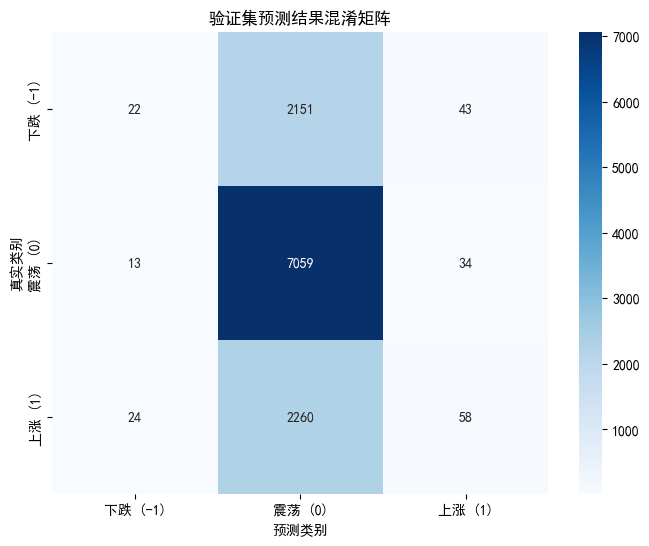


详细分类报告:
              precision    recall  f1-score   support

          -1       0.37      0.01      0.02      2216
           0       0.62      0.99      0.76      7106
           1       0.43      0.02      0.05      2342

    accuracy                           0.61     11664
   macro avg       0.47      0.34      0.28     11664
weighted avg       0.53      0.61      0.48     11664


特征重要性分析
1. 特征 'volume' : 0.3005
2. 特征 'ma_20' : 0.1457
3. 特征 'ma_5' : 0.1428
4. 特征 'hour' : 0.1351
5. 特征 'momentum_5' : 0.1170
6. 特征 'vol_ratio' : 0.0601
7. 特征 'vol_change' : 0.0523
8. 特征 'minute' : 0.0467


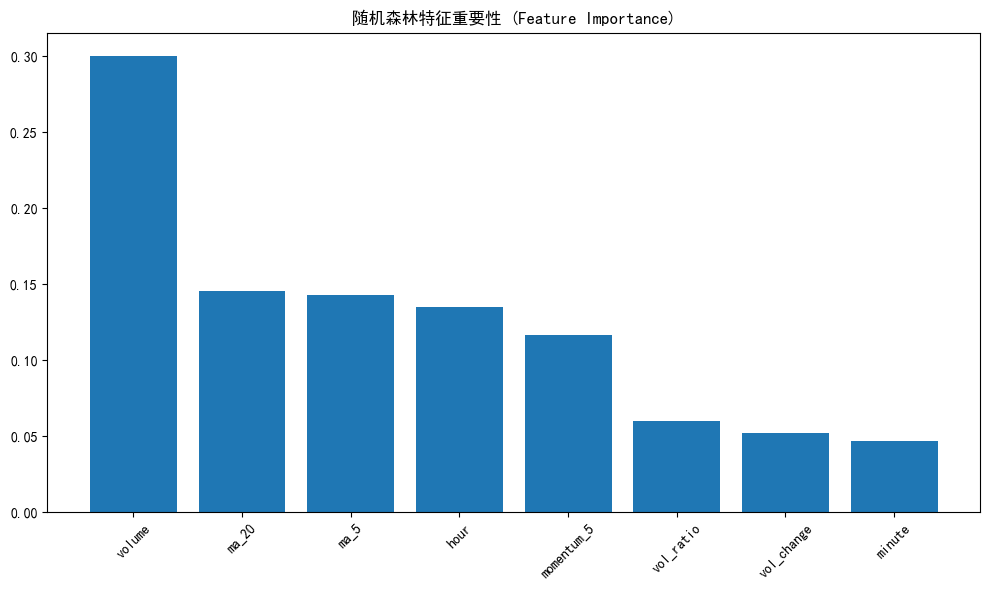

In [22]:
# 设置绘图风格 (解决中文显示问题)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

print("\n" + "="*50)
print("2020年验证集评估")
print("="*50)

# 预测
y_pred = best_model.predict(X_val)

# 1. 准确率
acc = accuracy_score(y_val, y_pred)
print(f"验证集准确率: {acc:.4f}")

# 2. 混淆矩阵
cm = confusion_matrix(y_val, y_pred)
print("\n混淆矩阵 (Confusion Matrix):")
print(cm)

# 绘制混淆矩阵热力图
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['下跌 (-1)', '震荡 (0)', '上涨 (1)'],
            yticklabels=['下跌 (-1)', '震荡 (0)', '上涨 (1)'])
plt.title('验证集预测结果混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.show()

# 3. 分类报告
print("\n详细分类报告:")
print(classification_report(y_val, y_pred))

# ==========================================
# 6. 特征重要性输出
# ==========================================
print("\n" + "="*50)
print("特征重要性分析")
print("="*50)

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1] # 降序排列

# 打印文本结果
for f in range(X_train.shape[1]):
    print(f"{f + 1}. 特征 '{feature_cols[indices[f]]}' : {importances[indices[f]]:.4f}")

# 绘制特征重要性图表
plt.figure(figsize=(10, 6))
plt.title("随机森林特征重要性 (Feature Importance)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_cols[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [23]:
import json

# ==========================================
# 7. 保存结果到 JSON 文件
# ==========================================
print("\n" + "="*50)
print("正在保存模型参数与结果...")
print("="*50)

# 整理要保存的数据
# 注意：Numpy 数据类型 (如 int64, float32) 需要转换为 Python 原生类型才能被 JSON 序列化
results_to_save = {
    "model_name": "RandomForest_5min_Vol_Enhanced",
    "best_params": grid_search.best_params_,              # 网格搜索找到的最佳参数
    "best_cv_score": float(grid_search.best_score_),      # 训练集上的最佳交叉验证得分
    "val_accuracy": float(acc),                           # 2020年验证集上的准确率
    "feature_importances": [                              # 特征重要性列表（按重要性排序）
        {"feature": feature_cols[i], "importance": float(importances[i])}
        for i in indices
    ],
    "confusion_matrix": cm.tolist()                       # 混淆矩阵 (转换为列表)
}

# 定义文件名
file_path = 'best_rf_params.json'

# 写入文件
try:
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(results_to_save, f, indent=4, ensure_ascii=False)
    print(f"成功！最佳参数及评估结果已保存至当前目录下的: {file_path}")
    
    # 打印文件内容预览
    print("\n文件内容预览 (Top 5 lines):")
    print(json.dumps(results_to_save, indent=4, ensure_ascii=False)[:500] + "...\n(更多内容见文件)")

except Exception as e:
    print(f"保存文件时发生错误: {e}")


正在保存模型参数与结果...
成功！最佳参数及评估结果已保存至当前目录下的: best_rf_params.json

文件内容预览 (Top 5 lines):
{
    "model_name": "RandomForest_5min_Vol_Enhanced",
    "best_params": {
        "class_weight": null,
        "max_depth": 7,
        "min_samples_leaf": 10,
        "n_estimators": 200
    },
    "best_cv_score": 0.6094195461284069,
    "val_accuracy": 0.6120541838134431,
    "feature_importances": [
        {
            "feature": "volume",
            "importance": 0.3005056289901128
        },
        {
            "feature": "ma_20",
            "importance": 0.14568087498808358
       ...
(更多内容见文件)


In [10]:
# 选择最重要的特征（约15个）
important_feature_cols = [
    'ma_5', 'ma_20', 'ma_60', 
    'price_ma5_ratio', 'price_ma20_ratio', 'price_ma60_ratio',
    'ma5_ma20_ratio',
    'momentum_5', 'momentum_10',
    'volatility_20',
    'position_in_20day_range',
    'price_change_1', 'price_change_5',
    'day_of_week',
    'close_lag1'
]

print(f"使用的特征数量: {len(important_feature_cols)}")
print("使用的特征列表:")
for i, feat in enumerate(important_feature_cols, 1):
    print(f"{i}. {feat}")

使用的特征数量: 15
使用的特征列表:
1. ma_5
2. ma_20
3. ma_60
4. price_ma5_ratio
5. price_ma20_ratio
6. price_ma60_ratio
7. ma5_ma20_ratio
8. momentum_5
9. momentum_10
10. volatility_20
11. position_in_20day_range
12. price_change_1
13. price_change_5
14. day_of_week
15. close_lag1
